# Matrix Factorization: Learning Hidden Taste

Collaborative filtering from notebook 2 hits a wall: the user-item matrix is mostly empty,
and nearest-neighbour similarity becomes unreliable with sparse data.

**Matrix factorization** solves both problems at once. Instead of asking "who else rated things
like user u?", it asks "what *kind* of person is user u, and what *kind* of item is item i?"
Both user and item get a short vector of learned numbers, and the predicted rating comes from
a single dot product.

One deliberate change from notebooks 1 and 2: this notebook uses a denser matrix
(`density=0.20`, about 20% of cells observed, versus 7% before). At 7% density the 516
training ratings cannot support the model's 2,000 embedding parameters, and matrix
factorization can only match the bias model from notebook 1. With 20% observed, the latent
structure is learnable and you can see factorization actually work. Keep in mind that
extreme sparsity limits every model in this course; notebook 4 returns to the sparser
7% setting.

This notebook builds matrix factorization from scratch in pure Python: the model equation,
gradient derivations, the SGD training loop, and the structure the embeddings discover.
The notebook ends at the scalability and cold-start limits that motivate notebook 4.

| Step | What we build |
|------|--------------|
| 1 | The latent factor idea and model equation |
| 2 | Random embedding initialisation and baseline sanity check |
| 3 | SGD training loop with L2 regularisation |
| 4 | Visualising what the embeddings learned |
| 5 | Cold start and scalability limits |

In [1]:
import random, math, matplotlib.pyplot as plt
%matplotlib inline

def make_ratings(n_users=80, n_items=120, n_factors=4, density=0.20, seed=42):
    random.seed(seed)
    U = [[random.gauss(0,1) for _ in range(n_factors)] for _ in range(n_users)]
    V = [[random.gauss(0,1) for _ in range(n_factors)] for _ in range(n_items)]
    bu = [random.gauss(0, 0.3) for _ in range(n_users)]
    bv = [random.gauss(0, 0.3) for _ in range(n_items)]
    mu = 3.5
    ratings = []
    for u in range(n_users):
        for v in range(n_items):
            if random.random() < density:
                r = mu + bu[u] + bv[v] + sum(U[u][k]*V[v][k] for k in range(n_factors))
                r = max(1.0, min(5.0, r + random.gauss(0, 0.3)))
                ratings.append((u, v, round(r)))
    return ratings, n_users, n_items

def train_val_split(ratings, val_frac=0.2, seed=42):
    random.seed(seed)
    shuffled = list(ratings)
    random.shuffle(shuffled)
    split = int(len(shuffled) * (1 - val_frac))
    return shuffled[:split], shuffled[split:]

def rmse(predictions):  # predictions: list of (pred, actual) tuples
    return math.sqrt(sum((p - a)**2 for p, a in predictions) / len(predictions))

ratings, N_USERS, N_ITEMS = make_ratings()
train, val = train_val_split(ratings)
print(f'{len(train)} train ratings, {len(val)} val ratings')

1556 train ratings, 390 val ratings


## Step 1: The Latent Factor Idea

Every user can be described by a short vector: [loves_action, hates_romance, prefers_shorts, ...].
Nobody wrote those labels. The model discovers them from patterns in the rating data.
The same goes for items. An action film that is short gets a vector pointing in the "action"
and "short" directions.

**Predicted rating** = the degree to which the user and item vectors align, plus bias terms:

```
r_hat(u, i) = mu + b_u + b_i + U[u] . V[i]
```

- **mu**: global mean rating
- **b_u**: user bias (does this user rate everything high?)
- **b_i**: item bias (does everyone rate this item high?)
- **U[u]**: user's latent factor vector, K numbers
- **V[i]**: item's latent factor vector, K numbers
- **U[u] . V[i]**: dot product: how much user tastes align with item profile

If the user loves action (large first component) and the film is action-heavy (large first
component), the dot product is large and the predicted rating rises.

**Connection to word embeddings.** In the embeddings notebook, each word got a vector learned
from co-occurrence patterns. Here, each user and each item gets a vector learned from rating
patterns. The mechanism is identical: a lookup table indexed by an ID, updated by gradient
descent. A word is to its context as a user is to the items they rated.

In [2]:
# The model equation in plain arithmetic.
# Toy example: K=2, one user, one item.

def dot(a, b):
    return sum(x * y for x, y in zip(a, b))

mu_demo  = 3.5
b_u_demo =  0.2    # this user rates above average
b_i_demo = -0.1   # this item is rated slightly below average

U_demo = [0.8, 0.3]    # user likes factor 0 a lot
V_demo = [0.7, -0.2]   # item is high on factor 0, low on factor 1

r_hat = mu_demo + b_u_demo + b_i_demo + dot(U_demo, V_demo)
print(f'Global mean:   {mu_demo}')
print(f'User bias:     {b_u_demo:+.2f}')
print(f'Item bias:     {b_i_demo:+.2f}')
print(f'Dot product:   {dot(U_demo, V_demo):.3f}')
print(f'Predicted r:   {r_hat:.3f}')

Global mean:   3.5
User bias:     +0.20
Item bias:     -0.10
Dot product:   0.500
Predicted r:   4.100


## Step 2: Initialising the Embeddings

The model has four sets of parameters:

| Parameter | Shape | Initialisation |
|-----------|-------|----------------|
| U: user embeddings | N_USERS x K | small random Gaussian |
| V: item embeddings | N_ITEMS x K | small random Gaussian |
| b_u: user biases | N_USERS | zero |
| b_v: item biases | N_ITEMS | zero |

We initialise embeddings with small Gaussian noise (sigma = 0.01) so predictions start near
the global mean. A good sanity check: before any training, val RMSE should match the
naive baseline that predicts mu for every rating.

**Why small, not zero?** If all embedding vectors were exactly zero, the dot product is zero
for every pair, and all gradients are also zero. Nothing would ever move. Small random values
break this symmetry.

In [3]:
K = 10  # embedding dimension
random.seed(42)
scale = 0.01
U_emb = [[random.gauss(0, scale) for _ in range(K)] for _ in range(N_USERS)]
V_emb = [[random.gauss(0, scale) for _ in range(K)] for _ in range(N_ITEMS)]
b_u   = [0.0] * N_USERS
b_v   = [0.0] * N_ITEMS
mu    = sum(r for _, _, r in train) / len(train)

def predict_mf(u, i):
    return mu + b_u[u] + b_v[i] + dot(U_emb[u], V_emb[i])

print(f'Global mean mu = {mu:.4f}')

Global mean mu = 3.2519


In [4]:
# Before training: predictions are near mu, so RMSE should match the mean baseline.
baseline_preds  = [(mu, r) for _, _, r in val]
mf_preds_before = [(predict_mf(u, i), r) for u, i, r in val]

print(f'Global-mean baseline RMSE: {rmse(baseline_preds):.4f}')
print(f'Untrained MF RMSE:         {rmse(mf_preds_before):.4f}')
print('Both are close: the tiny random embeddings add only noise.')

Global-mean baseline RMSE: 1.4053
Untrained MF RMSE:         1.4053
Both are close: the tiny random embeddings add only noise.


## Step 3: Training with SGD

The four-step training loop applies here unchanged: predict, score, assign blame, nudge.
Because we built the model in pure Python, we derive the gradients analytically.

### Deriving the gradients

The loss for one rating (u, i, r) is squared error:

```
L = (r - r_hat)^2    where r_hat = mu + b_u + b_i + U[u] . V[i]
```

Let e = r - r_hat (the prediction error). The chain rule gives:

```
dL/dU[u][k] = -2e * V[i][k]
dL/dV[i][k] = -2e * U[u][k]
dL/db_u[u]  = -2e
dL/db_v[i]  = -2e
```

The sign makes sense: if e > 0 (we under-predicted), increasing U[u][k] raises r_hat,
which reduces the error. Gradient descent steps in the direction of -dL, which is +2e * V[i][k].

### L2 regularisation

With K=10 and 80+120 entities, the model has (80+120) x 10 = 2000 embedding parameters.
Without a penalty, large embeddings can overfit the training ratings.

L2 regularisation adds lambda * ||U[u]||^2 to the loss for each user u seen in a batch.
This adds 2 * lambda * U[u][k] to each gradient, a constant "shrink toward zero" pressure.
Biases are typically not regularised.

The modified update rules:

```
U[u][k] += lr * (2e * V[i][k] - 2*lambda * U[u][k])
V[i][k] += lr * (2e * U[u][k] - 2*lambda * V[i][k])
b_u[u]  += lr * 2e
b_v[i]  += lr * 2e
```

In [5]:
def train_mf(U, V, bu, bv, mu, train_data, val_data,
             epochs=20, lr=0.01, lam=0.01):
    train_rmse_hist = []
    val_rmse_hist   = []

    for epoch in range(epochs):
        random.shuffle(train_data)
        for u, i, r in train_data:
            # 1. Predict
            r_hat = mu + bu[u] + bv[i] + dot(U[u], V[i])
            # 2. Score (error)
            e = r - r_hat
            # 3-4. Assign blame and nudge (analytical gradient update)
            bu[u] += lr * 2 * e
            bv[i] += lr * 2 * e
            for k in range(K):
                gu = 2 * e * V[i][k] - 2 * lam * U[u][k]
                gv = 2 * e * U[u][k] - 2 * lam * V[i][k]
                U[u][k] += lr * gu
                V[i][k] += lr * gv

        def eval_rmse(data):
            preds = [(mu + bu[u] + bv[i] + dot(U[u], V[i]), r) for u, i, r in data]
            return rmse(preds)

        tr = eval_rmse(train_data)
        va = eval_rmse(val_data)
        train_rmse_hist.append(tr)
        val_rmse_hist.append(va)
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:2d}  train RMSE={tr:.4f}  val RMSE={va:.4f}')

    return train_rmse_hist, val_rmse_hist

# Re-initialise fresh embeddings before training
random.seed(42)
U_emb = [[random.gauss(0, scale) for _ in range(K)] for _ in range(N_USERS)]
V_emb = [[random.gauss(0, scale) for _ in range(K)] for _ in range(N_ITEMS)]
b_u   = [0.0] * N_USERS
b_v   = [0.0] * N_ITEMS

train_h, val_h = train_mf(U_emb, V_emb, b_u, b_v, mu, train, val,
                           epochs=20, lr=0.01, lam=0.01)

Epoch  0  train RMSE=1.3584  val RMSE=1.3747
Epoch  5  train RMSE=1.2946  val RMSE=1.3593
Epoch 10  train RMSE=1.2871  val RMSE=1.3655
Epoch 15  train RMSE=1.2601  val RMSE=1.3601
Epoch 19  train RMSE=1.1395  val RMSE=1.3121


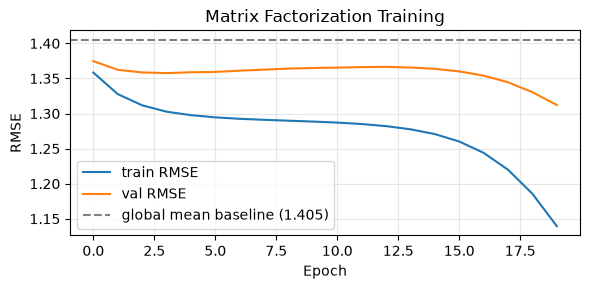

Final val RMSE: 1.3121  (baseline: 1.4053)


In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(train_h, label='train RMSE')
ax.plot(val_h,   label='val RMSE')
baseline = rmse([(mu, r) for _, _, r in val])
ax.axhline(baseline, color='gray', linestyle='--', label=f'global mean baseline ({baseline:.3f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.set_title('Matrix Factorization Training')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final val RMSE: {val_h[-1]:.4f}  (baseline: {baseline:.4f})')

## Step 4: What Did the Embeddings Learn?

The training data came from `make_ratings`, which gave every user and every item a hidden
4-dimensional taste vector drawn from a Gaussian. The model never saw those vectors, only
the ratings they produced. Did training recover the hidden structure?

Two checks:

1. **Scatter plot.** We project the learned K-dimensional embeddings to 2D by taking the
first two dimensions. Because the true factors are continuous draws, not discrete categories,
don't expect neat clusters: the picture should be a spread-out cloud. The structure lives in
the geometry, with similar-taste entities sitting near each other.
2. **Similarity recovery.** The generator is seeded, so we can replay its random draws and
recover the true taste vectors. That lets us test the claim directly: items that are close
in the *learned* space should also be close in the *true* factor space.

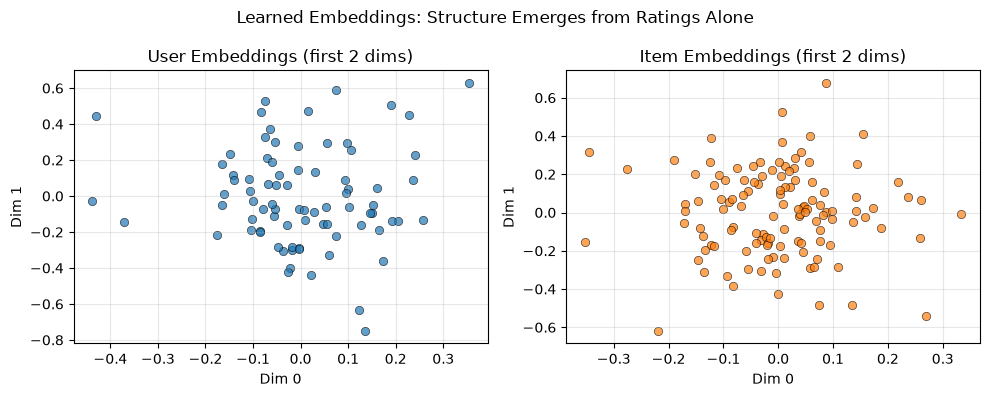

In [7]:
# Project to 2D: take the first two embedding dimensions.
user_x = [U_emb[u][0] for u in range(N_USERS)]
user_y = [U_emb[u][1] for u in range(N_USERS)]
item_x = [V_emb[i][0] for i in range(N_ITEMS)]
item_y = [V_emb[i][1] for i in range(N_ITEMS)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(user_x, user_y, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0].set_title('User Embeddings (first 2 dims)')
axes[0].set_xlabel('Dim 0'); axes[0].set_ylabel('Dim 1')
axes[0].grid(alpha=0.3)

axes[1].scatter(item_x, item_y, alpha=0.7, color='tab:orange',
               edgecolors='k', linewidth=0.5)
axes[1].set_title('Item Embeddings (first 2 dims)')
axes[1].set_xlabel('Dim 0'); axes[1].set_ylabel('Dim 1')
axes[1].grid(alpha=0.3)

plt.suptitle('Learned Embeddings: Structure Emerges from Ratings Alone')
plt.tight_layout()
plt.show()

In [8]:
# Sanity check: does learned similarity match the true hidden similarity?
# make_ratings drew the true taste vectors first under seed 42, so replaying
# those draws recovers the ground truth the model never saw.
random.seed(42)
U_true = [[random.gauss(0, 1) for _ in range(4)] for _ in range(N_USERS)]
V_true = [[random.gauss(0, 1) for _ in range(4)] for _ in range(N_ITEMS)]

def norm(v):
    n = math.sqrt(sum(x**2 for x in v))
    return n if n > 0 else 1.0

def cosine_sim(a, b):
    return dot(a, b) / (norm(a) * norm(b))

query = 0
sims = [(cosine_sim(V_emb[query], V_emb[i]), i) for i in range(N_ITEMS) if i != query]
sims.sort(reverse=True)

print(f'Items most similar to item {query} in the learned space:')
for sim, item_id in sims[:5]:
    true_sim = cosine_sim(V_true[query], V_true[item_id])
    print(f'  item {item_id:3d}  learned sim = {sim:.3f}   true sim = {true_sim:+.3f}')

avg_true_top = sum(cosine_sim(V_true[query], V_true[i]) for _, i in sims[:5]) / 5
avg_true_all = sum(cosine_sim(V_true[query], V_true[i]) for i in range(N_ITEMS) if i != query) / (N_ITEMS - 1)
print(f'\nAvg true similarity of the top-5 learned neighbours: {avg_true_top:.3f}')
print(f'Avg true similarity across all items:                 {avg_true_all:.3f}')

# One number for the whole space: correlation between true and learned
# similarity over every item pair.
pairs = [(i, j) for i in range(N_ITEMS) for j in range(i + 1, N_ITEMS)]
xs = [cosine_sim(V_true[i], V_true[j]) for i, j in pairs]
ys = [cosine_sim(V_emb[i], V_emb[j]) for i, j in pairs]
mx, my = sum(xs) / len(xs), sum(ys) / len(ys)
cov = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
corr = cov / math.sqrt(sum((x - mx)**2 for x in xs) * sum((y - my)**2 for y in ys))
print(f'Correlation(true sim, learned sim) over {len(pairs)} item pairs: {corr:.3f}')

Items most similar to item 0 in the learned space:
  item  83  learned sim = 0.971   true sim = +0.928
  item  89  learned sim = 0.925   true sim = +0.413
  item  57  learned sim = 0.902   true sim = +0.551
  item  48  learned sim = 0.887   true sim = +0.791
  item   3  learned sim = 0.879   true sim = +0.709

Avg true similarity of the top-5 learned neighbours: 0.678
Avg true similarity across all items:                 0.019
Correlation(true sim, learned sim) over 7140 item pairs: 0.557


## Step 5: Cold Start and Scalability

Matrix factorization works well in the offline setting, but it has real limits.

### Cold start

A new user arrives. They have no ratings. Their row in U is missing. You have no embedding,
and you cannot make personalised predictions. This is the **cold start problem**.

The same applies to new items. A film released today has no ratings yet. Its V vector is missing.

Common workarounds:
- Show popular items (no personalisation)
- Ask the user to rate a handful of seed items before making predictions
- Fall back to content-based features (genre, director, etc.) for new items

None of these is satisfying. Notebook 4 addresses cold start by incorporating
content features directly into the model architecture.

### Scalability

SGD over all observed ratings is sequential, one rating at a time. With millions of ratings
and millions of users, a single epoch can take minutes. New ratings do not immediately update
the embeddings; the model needs periodic retraining.

### Summary

| Property | Global Mean | Item Bias | Matrix Factorization |
|----------|-------------|-----------|----------------------|
| Sparsity handling | No problem | No problem | Handles well (dense factors) |
| Personalisation | None | Per item only | Yes, per user and item |
| Parameters | 1 | N_ITEMS | (N_USERS + N_ITEMS) x K |
| Cold start | N/A | Fine for users | Fails for both |
| Interpretability | Trivial | Easy | Factors are opaque |

## Your Turn

**1. Embedding dimension.** Retrain with K=2 and K=20 (epochs=20, lam=0.01). For each,
print the final val RMSE and the train-val gap (val_rmse - train_rmse).
K=2 underfits: not enough capacity to capture all four hidden factors.
K=20 fits better on val but shows a wider train-val gap.
At what K does the gap start to grow noticeably?

**2. Regularisation strength.** Train four models: `lam=0.001`, `lam=0.01`, `lam=0.1`, and
`lam=0.5` (epochs=20, K=10). For each, plot train and val RMSE. What happens to training
when `lam=0.5`? At what value does regularisation start hurting performance on val rather
than helping it?

**3. Factor recovery.** The synthetic data was generated with `n_factors=4`.
Train three models: K=2, K=4, K=8 (epochs=20, lam=0.01). Measure val RMSE for each.
Does K=4 do better than K=2? Does K=8 do better than K=4?
What does this tell you about the information content in the ratings?

> **Next:** [Neural Collaborative Filtering](4_neural_collaborative_filtering.ipynb): replacing the dot product with an MLP